In [4]:
# ==========================================================================
# GitHub表示用（一番最初に実行してください）
# ==========================================================================
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# グラフのダークモード対策（背景に薄いグレーのグリッドを敷く）
plt.style.use('ggplot') 

# データフレーム（表）の表示行数・列数を最大10に制限してスッキリさせる
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

# 不要な警告（Warning）を非表示にする
warnings.filterwarnings('ignore')

In [ ]:
# 有名な「iris（アイリス）」データセットを使って分析の練習を実施

In [5]:
from sklearn.datasets import load_iris

# irisデータを読み込む
# as_frame=True と書いておくと、Pandasのデータフレームになる
iris = load_iris(as_frame=True)
# 説明変数のデータをデータフレームとして取り出す
X = iris.data
# 目的変数（正解・花のクラスのデータを取り出す
y = iris.target
# yの列名を 'species'に変更して突合わせる
df_iris = pd.concat([X, y.rename('species')], axis=1)
# 結合したデータの全体像（上から5行）を表示
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


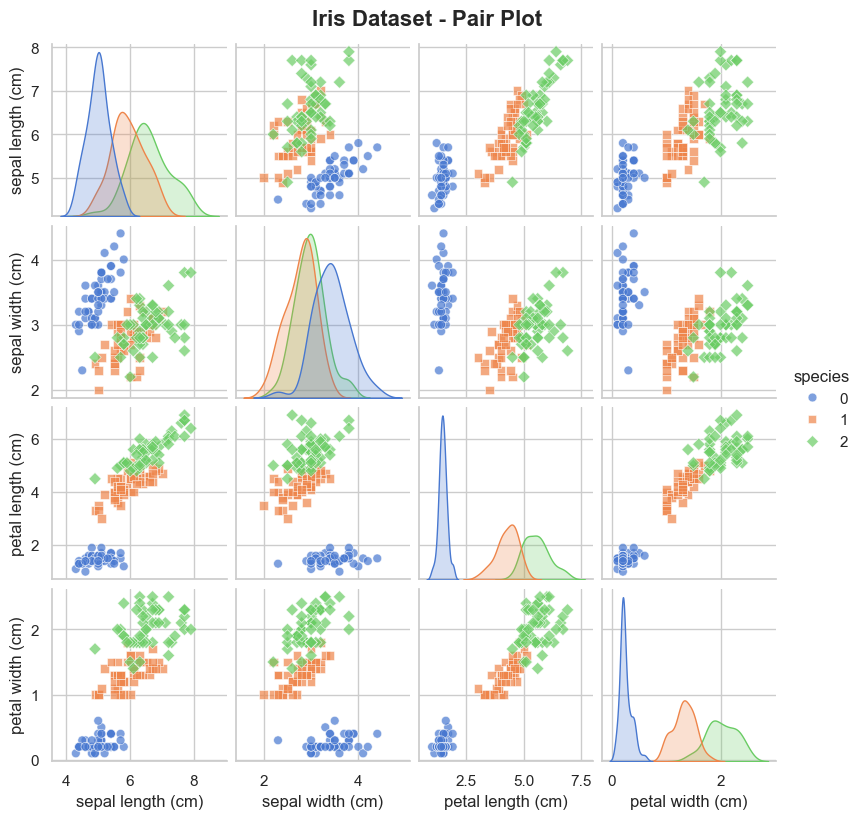

In [12]:
import seaborn as sns

# 全体のデザインを白背景・グリッド線付き
sns.set_theme(style='whitegrid', context='notebook')
# グラフ全体の大きさと画質（dpi）を上げて、文字をくっきりさせる
# 散布図をまとめて出力する
g = sns.pairplot(
    data=df_iris, 
    hue='species',               # 花の種類（0, 1, 2）で色分けする
    height=2.0,                  # ★ここ！1マスの高さを2.0インチに小さくする（デフォルトは2.5）
    aspect=1.0,                  # ★1マスの「幅 ÷ 高さ」の比率（1.0なら綺麗な正方形になる）
    palette='muted',             # 目に優しい上品なカラーパレット
    markers=['o', 's', 'D'],     # 種類ごとに丸・四角・ダイヤと形を変える（見やすさアップ！）
    diag_kind='kde',             # 斜めのラインには、データの山（密度関数）を描く
    plot_kws={'alpha': 0.7, 'edgecolor': 'w', 's': 40} # 点の透明度、白フチ、大きさを調整
)

# タイトルをつけて全体のバランスを整える
g.fig.suptitle('Iris Dataset - Pair Plot', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 上記の傾向から説明変数（X）を2つのpetalの列だけにする
X_petals = X[['petal length (cm)', 'petal width (cm)']]

# データを「練習用」と「テスト用」に分ける（irisは150行なので、半分ずつ）
X_train, X_test, y_train, y_test = train_test_split(
    X_petals, y, test_size=0.5, random_state=42, stratify=y
)

# シンプルな「決定木（DecisionTree）」の分類ロボットを連れてくる
# 枝分かれの深さ（max_depth）を3回までに制限しておく
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 学習（fit）させる
model_tree.fit(X_train, y_train)

# テストデータを使って予測（predict）して、正解率を出す
y_pred = model_tree.predict(X_test)
print(f"2つのpetal（花弁）だけで作った決定木の正解率: {accuracy_score(y_test, y_pred):.3f}")

2つのpetal（花弁）だけで作った決定木の正解率: 0.907


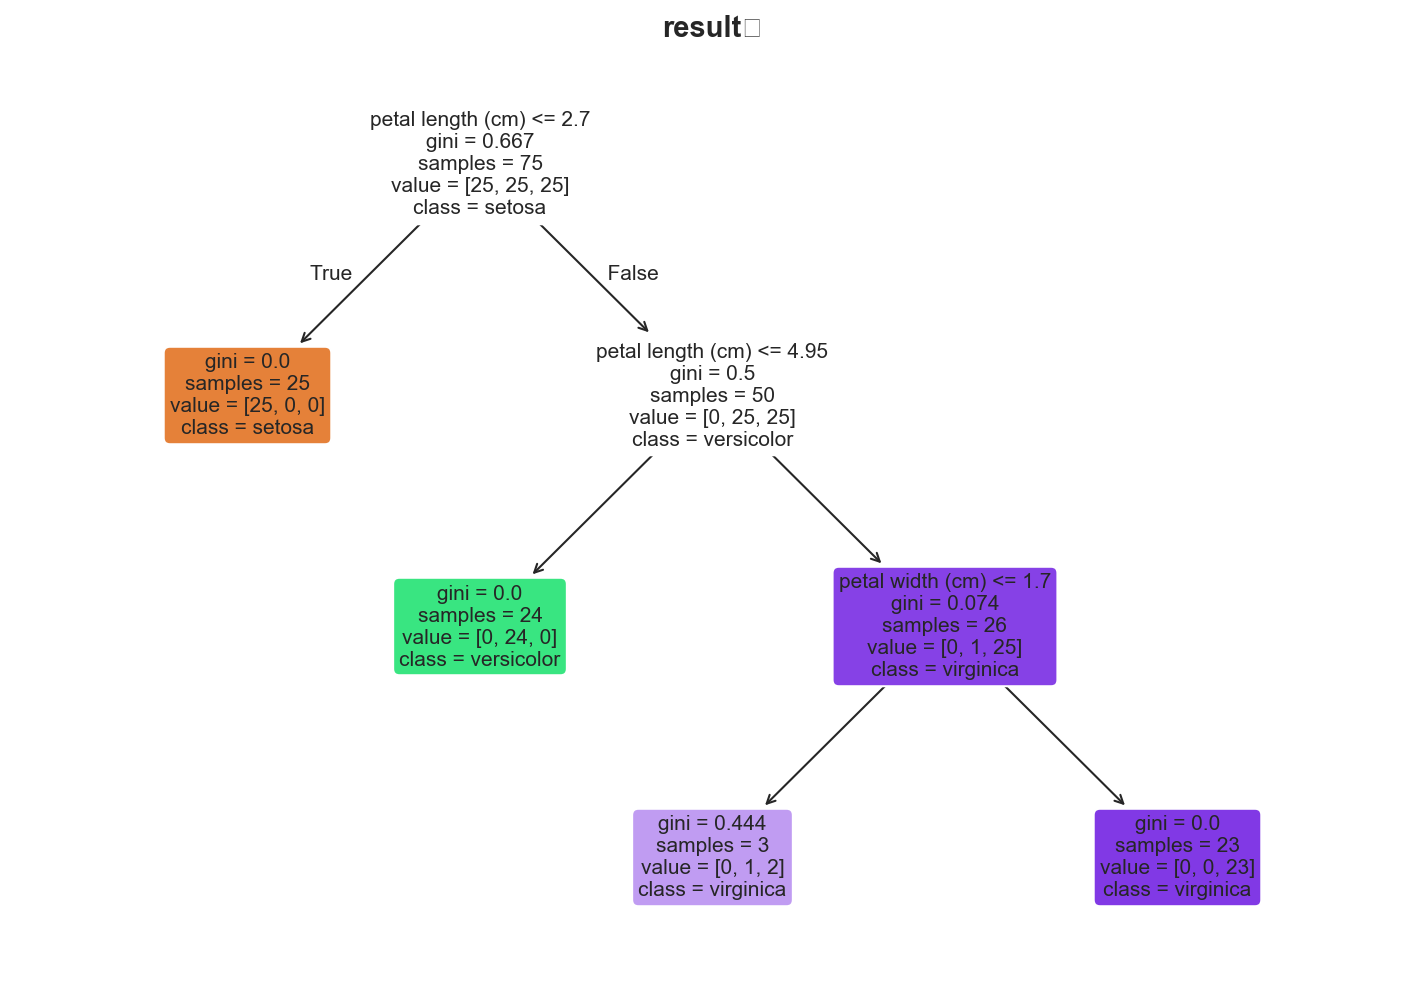

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# グラフ全体の大きさを指定（文字が潰れないように少し大きめにするよ）
plt.figure(figsize=(12, 8), dpi=150)
# 決定木の図面を描く（プロがきれいに見せるためのオプション満載！）
plot_tree(
    model_tree,
    feature_names=X_train.columns.tolist(), # ヒントの名前（petal_lengthなど）を表示する
    class_names=iris.target_names.tolist(), # 花の種類（setosaなど）の名前を表示する
    filled=True,                            # 種類ごとにボックスを綺麗に色分けする
    rounded=True,                           # ボックスの角を丸くして見やすくする
    fontsize=10                             # 文字の大きさ
)
# 3. タイトルをつけて表示
plt.title("result）", fontsize=14, fontweight='bold')
plt.show()

In [16]:
#説明変数の調整をまとめて行う方法
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 特徴量の組み合わせを辞書にする
strategy_dict = {
    'PlanA：花弁（petal）の2つだけ': ['petal length (cm)', 'petal width (cm)'],
    'PlanB：がく片（sepal）の2つだけ': ['sepal length (cm)', 'sepal width (cm)'],
    'PlanC：すべて（4つ全部）': X.columns.tolist()
}

# 結果を記録するための空っぽの辞書
strategy_results = {}

# 3. for文で、作戦を1つずつ自動で実験していく！
for name, feature_list in strategy_dict.items():
    
    # 作戦ごとの特徴量だけを抜き出す
    X_selected = X[feature_list]
    
    # データを練習用とテスト用に分ける（条件を揃えるために random_state は固定！）
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.5, random_state=42, stratify=y
    )
    
    # 決定木に学習させて予測する
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # 正解率を計算して記録！
    strategy_results[name] = accuracy_score(y_test, y_pred)

# 4. 最後にスコアボードとして一気に発表！
print("=== 特徴量の組み合わせ別 正解率選手権 ===")
for name, score in strategy_results.items():
    print(f"{name} ➔ 正解率: {score:.3f}")

=== 特徴量の組み合わせ別 正解率選手権 ===
PlanA：花弁（petal）の2つだけ ➔ 正解率: 0.907
PlanB：がく片（sepal）の2つだけ ➔ 正解率: 0.627
PlanC：すべて（4つ全部） ➔ 正解率: 0.907


In [17]:
# 決定木の深さを変えてみる方法
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_petals = X[['petal length (cm)', 'petal width (cm)']]
X_train, X_test, y_train, y_test = train_test_split(
    X_petals, y, test_size=0.5, random_state=42, stratify=y
)

# 試したい深さリストにする
depth_options = [1, 2, 3, 4, 5]

# 結果を記録する箱
param_results = {}

# for文で、設定を1つずつ変えながら自動実験！
for depth in depth_options:
    
    # ➔ 今回の「設定の数字（depth）」を渡す
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # ➔ 学習して予測する
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # ➔ スコアを記録（キーを設定の数字にするのがスマート！）
    param_results[f"木の深さ = {depth}"] = accuracy_score(y_test, y_pred)

print("=== 決定木の深さ別 正解率 ===")
for setting, score in param_results.items():
    print(f"{setting} ➔ 正解率: {score:.3f}")

=== 決定木の深さ別 正解率 ===
木の深さ = 1 ➔ 正解率: 0.667
木の深さ = 2 ➔ 正解率: 0.907
木の深さ = 3 ➔ 正解率: 0.907
木の深さ = 4 ➔ 正解率: 0.880
木の深さ = 5 ➔ 正解率: 0.893


In [22]:

import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# 試したい設定の組み合わせを「辞書」で指定する
# キーには設定名、値には試したい数字のリストを入れるよ
param_grid = {
    'n_estimators': np.arange(10, 101, 10),  # 集める木の数
    'max_depth': [2, 3, 4]          # それぞれの木の深さ
}

# データを5分割するけど、どのグループにも3種類の花が「均等な比率」で混ざるように強制する設定
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# グリッドサーチの司令塔ロボットを作る
# cv=5 は「データを5グループに分けて、公平に使い回しながらテストしてね」という実務の鉄板設定（交差検証）
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf, # 5が標準、10にすると制度は上がるが計算時間がかかるので注意
    scoring='accuracy' # 「正解率」で一番高いやつを決めるよ
)

# 最強ヒントのデータを使って、全9パターンを一気に自動実験（fit）！
grid_search.fit(X_train, y_train)

# 結果
print("=== 総当たり戦の結果 ===")
print(f"一番スコアが良かった: {grid_search.best_params_}")
print(f"その時の正解率: {grid_search.best_score_:.3f}")

# 自動で完成した「一番」を取り出せる！
best_ai_model = grid_search.best_estimator_

# best_ai_model を使っていつでも本番の予測ができるよ！
y_pred = best_ai_model.predict(X_test)

=== 総当たり戦の結果 ===
一番スコアが良かった: {'max_depth': 2, 'n_estimators': np.int64(10)}
その時の正解率: 0.987
